## 3.Data cleaning ##

In [ ]:


# -------------------------------------------------
# STEP 1: Import Libraries
# -------------------------------------------------
import pandas as pd
import numpy as np

# -------------------------------------------------
# STEP 2: Load Dataset
# -------------------------------------------------
data = pd.read_csv(r"C:\YouTube_Social_Media_Anlytics_Project\data\raw\youtube_data.csv")

print("Original Dataset")
print(data.head())

# -------------------------------------------------
# STEP 3: Remove Duplicate Rows
# -------------------------------------------------
data = data.drop_duplicates()

# -------------------------------------------------
# STEP 4: Remove Missing Values
# -------------------------------------------------
data = data.dropna()

# -------------------------------------------------
# STEP 5: Convert Date Format
# -------------------------------------------------
data['published_at'] = pd.to_datetime(data['published_at'])

# -------------------------------------------------
# STEP 6: Reset Index
# -------------------------------------------------
data = data.reset_index(drop=True)

print("Cleaned Dataset")
print(data.head())



Original Dataset
      video_id                                              title  \
0  65CASowfnKs  AI Tutorial for Beginners 2026: How To Use AI ...   
1  Yq0QkCxoTHM  Google’s AI Course for Beginners (in 10 minutes)!   
2  0Tch0N5nsRU  You’re not behind (yet): How to learn AI in 18...   
3  9c7zh2MkslY  You’re Not Behind (Yet): How to Learn AI in 29...   
4  yHk7Vavmc7Q  AI Tools EXPLAINED:  How to Use Them? (2025 Gu...   

         channel          published_at  
0  Mikey No Code  2026-03-11T14:05:19Z  
1        Jeff Su  2023-11-14T13:00:33Z  
2    Dan Martell  2026-03-05T14:00:01Z  
3    Futurepedia  2025-07-31T18:50:11Z  
4      AI Master  2024-12-12T14:01:02Z  
Cleaned Dataset
      video_id                                              title  \
0  65CASowfnKs  AI Tutorial for Beginners 2026: How To Use AI ...   
1  Yq0QkCxoTHM  Google’s AI Course for Beginners (in 10 minutes)!   
2  0Tch0N5nsRU  You’re not behind (yet): How to learn AI in 18...   
3  9c7zh2MkslY  You’re Not Beh

## 4.Exploratory Data Analysis (EDA) ##

Videos per Channel
channel
Mikey No Code              3
Jeff Su                    2
Futurepedia                2
Dan Martell                1
AI Master                  1
WebKnower                  1
edureka!                   1
Simplilearn                1
theMITmonk                 1
Kevin Stratvert            1
Kellan Henneberry          1
Ed Hill | AI Automation    1
AI Alfie                   1
Moritz | AI Builder        1
Roboverse                  1
freeCodeCamp.org           1
Name: count, dtype: int64


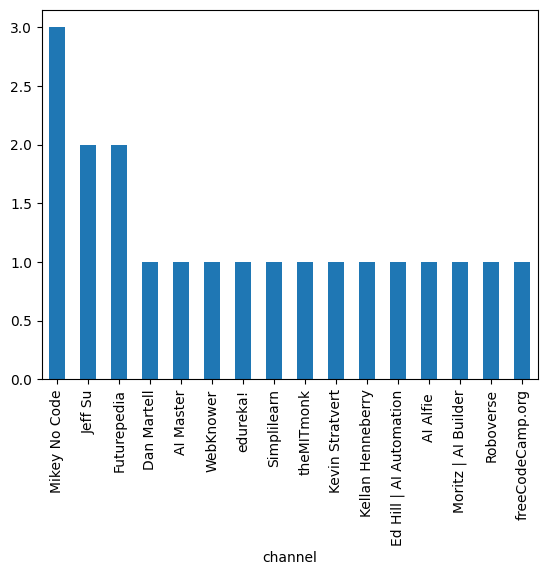

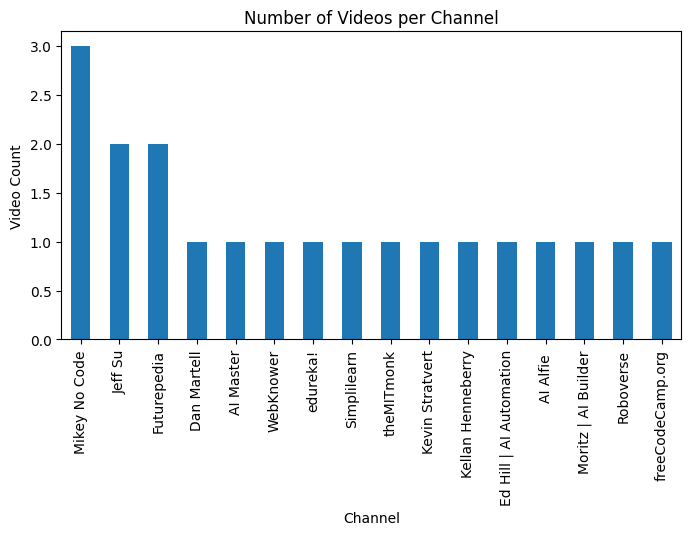

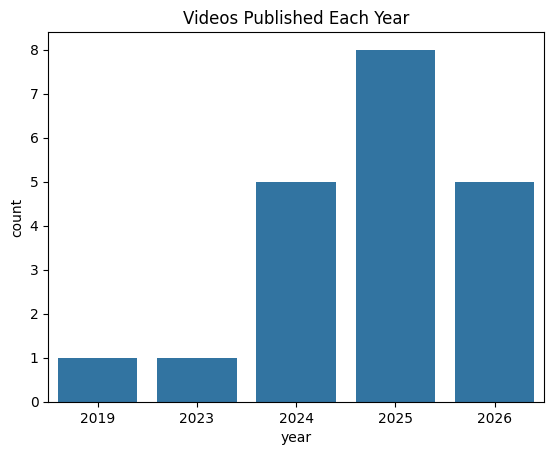

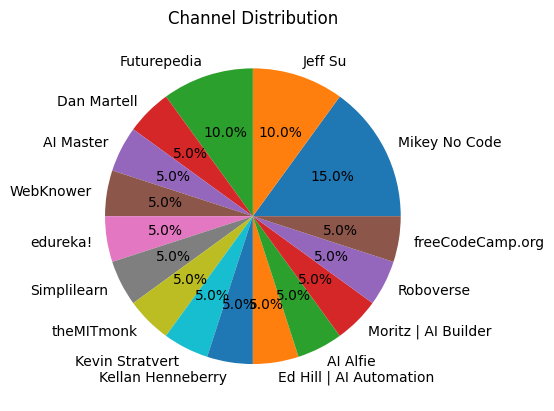

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
channel_count = data['channel'].value_counts()

print("Videos per Channel")
print(channel_count)
channel_count.plot(kind='bar')

# -------------------------------------------------
# GRAPH 1: Videos per Channel
# -------------------------------------------------
plt.figure(figsize=(8,4))

data['channel'].value_counts().plot(kind='bar')

plt.title("Number of Videos per Channel")
plt.xlabel("Channel")
plt.ylabel("Video Count")

plt.show()

# -------------------------------------------------
# GRAPH 2: Videos Published per Year
# -------------------------------------------------
data['published_at'] = pd.to_datetime(data['published_at'])

data['year'] = data['published_at'].dt.year

sns.countplot(x='year', data=data)

plt.title("Videos Published Each Year")
plt.show()

# -------------------------------------------------
# GRAPH 3: Channel Distribution Pie Chart
# -------------------------------------------------
data['channel'].value_counts().plot(kind='pie', autopct='%1.1f%%')

plt.title("Channel Distribution")
plt.show()


## 5.Content-Based Social Media Analysis (Topic Analysis)-visualization ##

Dataset Preview:
      video_id                                              title  \
0  65CASowfnKs  AI Tutorial for Beginners 2026: How To Use AI ...   
1  Yq0QkCxoTHM  Google’s AI Course for Beginners (in 10 minutes)!   
2  0Tch0N5nsRU  You’re not behind (yet): How to learn AI in 18...   
3  9c7zh2MkslY  You’re Not Behind (Yet): How to Learn AI in 29...   
4  yHk7Vavmc7Q  AI Tools EXPLAINED:  How to Use Them? (2025 Gu...   

         channel          published_at  
0  Mikey No Code  2026-03-11T14:05:19Z  
1        Jeff Su  2023-11-14T13:00:33Z  
2    Dan Martell  2026-03-05T14:00:01Z  
3    Futurepedia  2025-07-31T18:50:11Z  
4      AI Master  2024-12-12T14:01:02Z  

Discovered Topics:

Topic 1:
['mo', 'beginners', 'make', 'scratch', 'course', 'python', 'tutorial', 'minutes', 'learn', 'ai']

Topic 2:
['app', 'google', 'tools', 'beginners', 'use', 'n8n', '2026', 'tutorial', 'build', 'ai']

Topic 3:
['agents', 'guide', 'explained', '2025', 'tutorial', 'intelligence', 'artificial', 'co

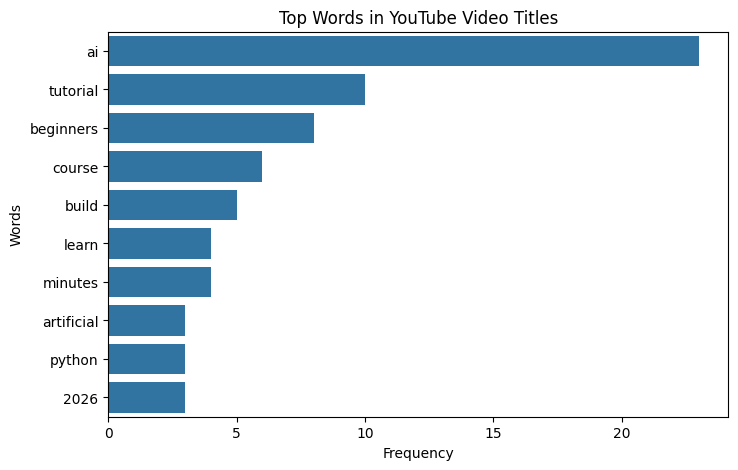

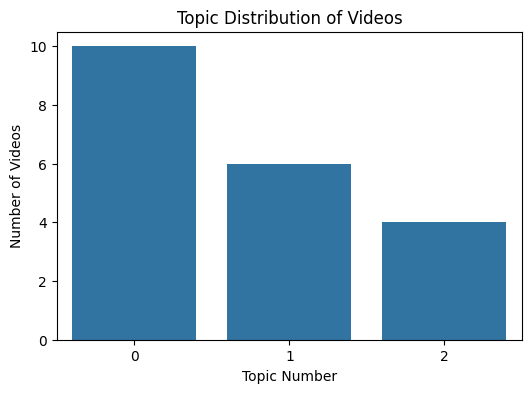

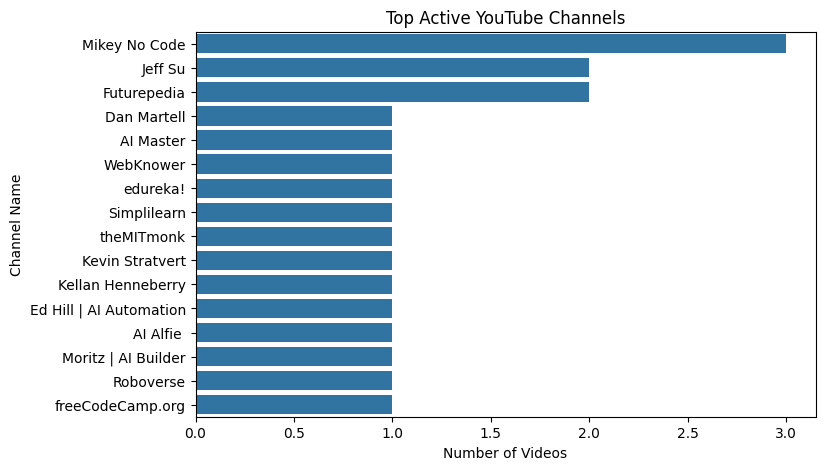

In [6]:
# ===============================
# STEP 1: Import Libraries
# ===============================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation


# ===============================
# STEP 2: Load Dataset
# ===============================
data = pd.read_csv(r"C:\YouTube_Social_Media_Anlytics_Project\data\raw\youtube_data.csv")

print("Dataset Preview:")
print(data.head())


# ===============================
# STEP 3: Text Vectorization
# ===============================
vectorizer = CountVectorizer(stop_words='english')

X = vectorizer.fit_transform(data['title'])


# ===============================
# STEP 4: Topic Modeling (LDA)
# ===============================
lda = LatentDirichletAllocation(n_components=3, random_state=42)

lda.fit(X)


# ===============================
# STEP 5: Display Topics
# ===============================
words = vectorizer.get_feature_names_out()

print("\nDiscovered Topics:\n")

for i, topic in enumerate(lda.components_):
    
    print(f"Topic {i+1}:")
    
    topic_words = [words[j] for j in topic.argsort()[-10:]]
    
    print(topic_words)
    
    print()


# ===============================
# VISUALIZATION 1
# Top Words in Titles
# ===============================
word_freq = pd.DataFrame({
    
    'word': vectorizer.get_feature_names_out(),
    
    'count': X.toarray().sum(axis=0)
})

top_words = word_freq.sort_values(by='count', ascending=False).head(10)

plt.figure(figsize=(8,5))

sns.barplot(x='count', y='word', data=top_words)

plt.title("Top Words in YouTube Video Titles")

plt.xlabel("Frequency")

plt.ylabel("Words")

plt.show()


# ===============================
# VISUALIZATION 2
# Topic Distribution
# ===============================
topic_results = lda.transform(X)

data['topic'] = topic_results.argmax(axis=1)

plt.figure(figsize=(6,4))

sns.countplot(x='topic', data=data)

plt.title("Topic Distribution of Videos")

plt.xlabel("Topic Number")

plt.ylabel("Number of Videos")

plt.show()


# ===============================
# VISUALIZATION 3
# Channel vs Number of Videos
# ===============================
channel_counts = data['channel'].value_counts()

plt.figure(figsize=(8,5))

sns.barplot(x=channel_counts.values, y=channel_counts.index)

plt.title("Top Active YouTube Channels")

plt.xlabel("Number of Videos")

plt.ylabel("Channel Name")

plt.show()

## 6.Structure Based Analysis (Network) ##

Dataset Preview:

      video_id                                              title  \
0  65CASowfnKs  AI Tutorial for Beginners 2026: How To Use AI ...   
1  Yq0QkCxoTHM  Google’s AI Course for Beginners (in 10 minutes)!   
2  0Tch0N5nsRU  You’re not behind (yet): How to learn AI in 18...   
3  9c7zh2MkslY  You’re Not Behind (Yet): How to Learn AI in 29...   
4  yHk7Vavmc7Q  AI Tools EXPLAINED:  How to Use Them? (2025 Gu...   

         channel          published_at  
0  Mikey No Code  2026-03-11T14:05:19Z  
1        Jeff Su  2023-11-14T13:00:33Z  
2    Dan Martell  2026-03-05T14:00:01Z  
3    Futurepedia  2025-07-31T18:50:11Z  
4      AI Master  2024-12-12T14:01:02Z  


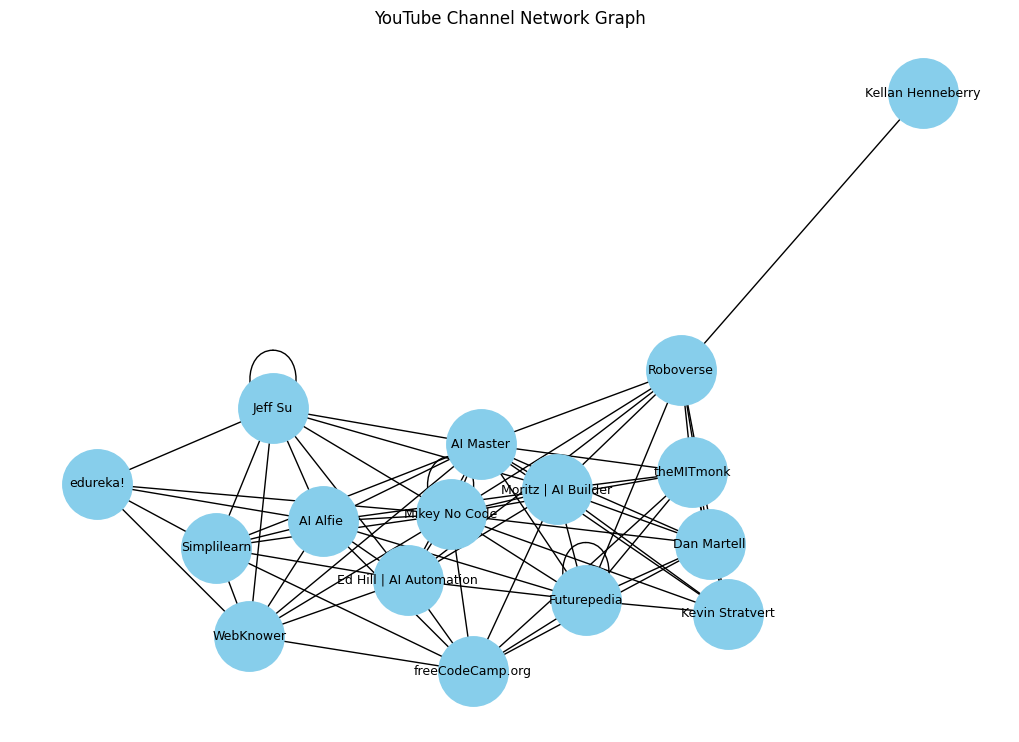


Detected Communities:

Community 1
Moritz | AI Builder
Kellan Henneberry
Futurepedia
AI Master
Kevin Stratvert
Dan Martell
theMITmonk
Roboverse

Community 2
Simplilearn
Mikey No Code
edureka!
Ed Hill | AI Automation
Jeff Su
WebKnower
AI Alfie 
freeCodeCamp.org


Most Influential / Active Channels:

channel
Mikey No Code      3
Jeff Su            2
Futurepedia        2
Dan Martell        1
AI Master          1
WebKnower          1
edureka!           1
Simplilearn        1
theMITmonk         1
Kevin Stratvert    1
Name: count, dtype: int64


In [4]:
# ==========================================================
# PRACTICAL 6 : STRUCTURE BASED SOCIAL MEDIA ANALYTICS MODEL
# ==========================================================

# STEP 1: Import Libraries
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer


# STEP 2: Load Dataset
data = pd.read_csv(r"C:\YouTube_Social_Media_Anlytics_Project\data\raw\youtube_data.csv")

print("Dataset Preview:\n")
print(data.head())


# ==========================================================
# STEP 3: Extract Keywords from Video Titles
# ==========================================================

vectorizer = CountVectorizer(stop_words='english')

X = vectorizer.fit_transform(data['title'])

keywords = vectorizer.get_feature_names_out()


# ==========================================================
# STEP 4: Create Network Graph
# ==========================================================

G = nx.Graph()

# Add nodes (channels)
for channel in data["channel"].unique():
    G.add_node(channel)


# Add edges if channels have similar titles
for i in range(len(data)):
    for j in range(i+1, len(data)):
        
        words_i = set(data['title'][i].lower().split())
        words_j = set(data['title'][j].lower().split())
        
        common = words_i.intersection(words_j)
        
        if len(common) >= 2:   # If titles share 2+ words
            G.add_edge(data['channel'][i], data['channel'][j])


# ==========================================================
# STEP 5: Visualize Network Graph
# ==========================================================

plt.figure(figsize=(10,7))

pos = nx.spring_layout(G)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=2500,
    node_color="skyblue",
    font_size=9
)

plt.title("YouTube Channel Network Graph")

plt.show()


# ==========================================================
# STEP 6: Community Detection
# ==========================================================

from networkx.algorithms import community

communities = community.greedy_modularity_communities(G)

print("\nDetected Communities:\n")

for i, c in enumerate(communities):
    
    print(f"Community {i+1}")
    
    for channel in list(c):
        print(channel)
        
    print()


# ==========================================================
# STEP 7: Influence Analysis (Most Active Channels)
# ==========================================================

channel_activity = data['channel'].value_counts()

print("\nMost Influential / Active Channels:\n")

print(channel_activity.head(10))

## 7.Dashboard using Streamlit ##

## 8.Creative Campaign Design for Social Media Promotion ##

Dataset Preview:
      video_id                                              title  \
0  65CASowfnKs  AI Tutorial for Beginners 2026: How To Use AI ...   
1  Yq0QkCxoTHM  Google’s AI Course for Beginners (in 10 minutes)!   
2  0Tch0N5nsRU  You’re not behind (yet): How to learn AI in 18...   
3  9c7zh2MkslY  You’re Not Behind (Yet): How to Learn AI in 29...   
4  yHk7Vavmc7Q  AI Tools EXPLAINED:  How to Use Them? (2025 Gu...   

         channel          published_at  
0  Mikey No Code  2026-03-11T14:05:19Z  
1        Jeff Su  2023-11-14T13:00:33Z  
2    Dan Martell  2026-03-05T14:00:01Z  
3    Futurepedia  2025-07-31T18:50:11Z  
4      AI Master  2024-12-12T14:01:02Z  

Top Campaign Keywords:
         word  count
12         ai     23
60   tutorial     10
20  beginners      8
27     course      6
22      build      5

Campaign Name: AI Learning Revolution 2026


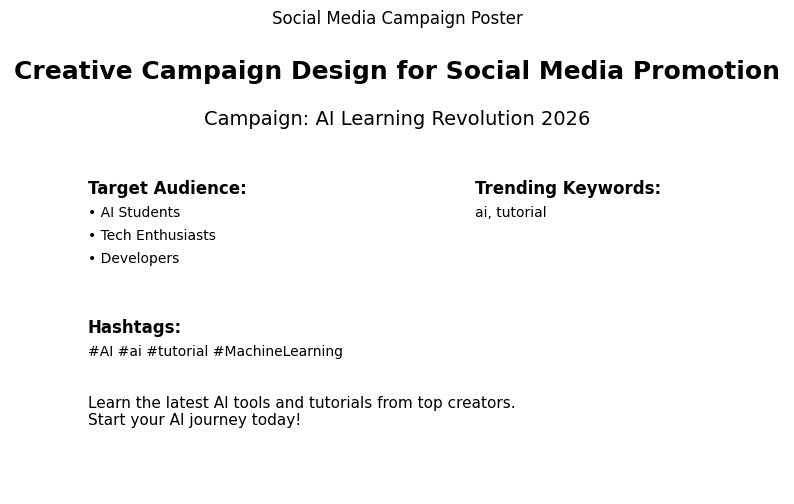

In [8]:
# ==========================================================
# PRACTICAL 8 : CREATIVE CAMPAIGN DESIGN FOR SOCIAL MEDIA
# ==========================================================

# STEP 1: Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer


# STEP 2: Load Dataset
data = pd.read_csv(r"C:\YouTube_Social_Media_Anlytics_Project\data\raw\youtube_data.csv")

print("Dataset Preview:")
print(data.head())


# ==========================================================
# STEP 3: Find Trending Keywords From Video Titles
# ==========================================================

vectorizer = CountVectorizer(stop_words='english')

X = vectorizer.fit_transform(data['title'])

word_freq = pd.DataFrame({
    'word': vectorizer.get_feature_names_out(),
    'count': X.toarray().sum(axis=0)
})

top_words = word_freq.sort_values(by="count", ascending=False).head(5)

print("\nTop Campaign Keywords:")
print(top_words)


# ==========================================================
# STEP 4: Generate Campaign Name
# ==========================================================

keyword1 = top_words.iloc[0]["word"]
keyword2 = top_words.iloc[1]["word"]

campaign_name = f"AI Learning Revolution 2026"

print("\nCampaign Name:", campaign_name)


# ==========================================================
# STEP 5: Create Poster Using Matplotlib
# ==========================================================

plt.figure(figsize=(10,6))

plt.text(0.5,0.9,"Creative Campaign Design for Social Media Promotion",
         fontsize=18,ha='center',weight='bold')

plt.text(0.5,0.8,f"Campaign: {campaign_name}",
         fontsize=14,ha='center')

plt.text(0.1,0.65,"Target Audience:",fontsize=12,weight='bold')
plt.text(0.1,0.6,"• AI Students")
plt.text(0.1,0.55,"• Tech Enthusiasts")
plt.text(0.1,0.50,"• Developers")

plt.text(0.6,0.65,"Trending Keywords:",fontsize=12,weight='bold')
plt.text(0.6,0.6,f"{keyword1}, {keyword2}")

plt.text(0.1,0.35,"Hashtags:",fontsize=12,weight='bold')
plt.text(0.1,0.30,f"#AI #{keyword1} #{keyword2} #MachineLearning")

plt.text(0.1,0.15,
"Learn the latest AI tools and tutorials from top creators.\n"
"Start your AI journey today!",
fontsize=11)

plt.axis('off')

plt.title("Social Media Campaign Poster")

plt.savefig("ai_campaign_poster.png")

plt.show()

## 9: Competitor Activity Analysis ##

Dataset Preview
      video_id                                              title  \
0  65CASowfnKs  AI Tutorial for Beginners 2026: How To Use AI ...   
1  Yq0QkCxoTHM  Google’s AI Course for Beginners (in 10 minutes)!   
2  0Tch0N5nsRU  You’re not behind (yet): How to learn AI in 18...   
3  9c7zh2MkslY  You’re Not Behind (Yet): How to Learn AI in 29...   
4  yHk7Vavmc7Q  AI Tools EXPLAINED:  How to Use Them? (2025 Gu...   

         channel          published_at  
0  Mikey No Code  2026-03-11T14:05:19Z  
1        Jeff Su  2023-11-14T13:00:33Z  
2    Dan Martell  2026-03-05T14:00:01Z  
3    Futurepedia  2025-07-31T18:50:11Z  
4      AI Master  2024-12-12T14:01:02Z  

Companies Selected
<ArrowStringArray>
['Infosys', 'Tata Consultancy Services']
Length: 2, dtype: str

Upload Activity
company
Infosys                      3
Tata Consultancy Services    2
Name: count, dtype: int64


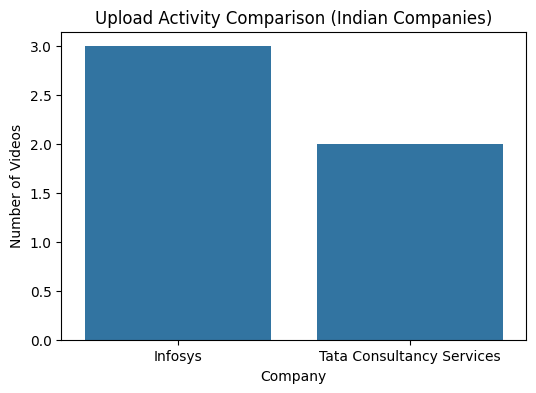


Posting Trend
company  Infosys  Tata Consultancy Services
year                                       
2023         NaN                        1.0
2024         NaN                        1.0
2026         3.0                        NaN


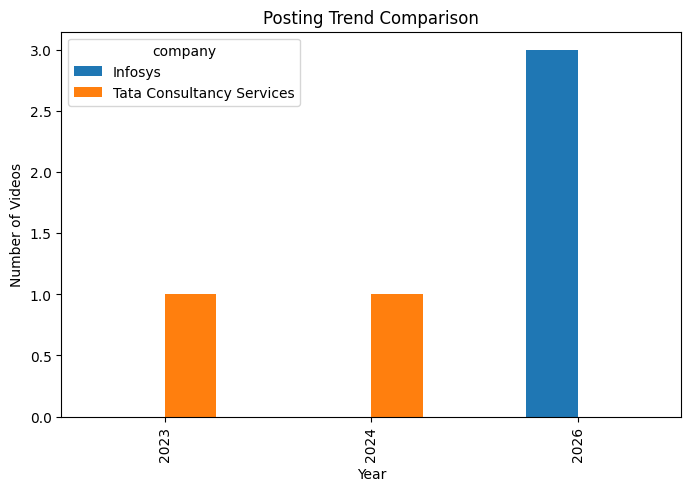


Top Keywords Used
         word  count
4          ai      6
8   beginners      3
20   tutorial      3
9       build      2
6         app      2
1        2026      2
15     google      2
3          99      1
2          39      1
0          10      1


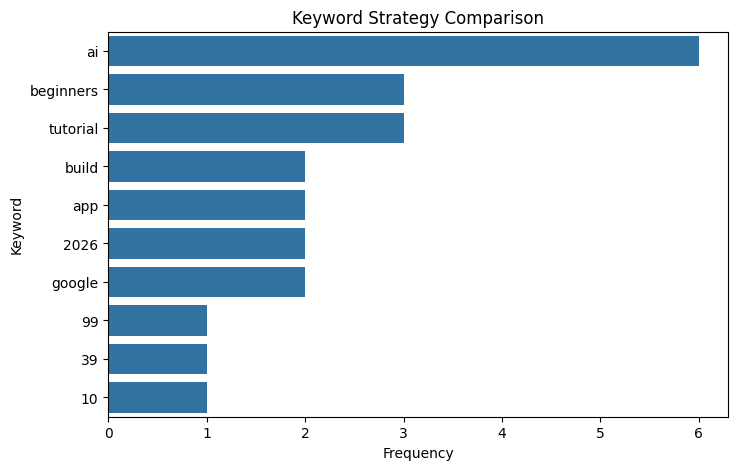


--- Competitor Insights ---
Infosys is more active in posting content.
Both companies focus on technology and AI related content strategies.


In [22]:
# ==========================================================
# PRACTICAL 9 : COMPETITOR ACTIVITY ANALYSIS
# ==========================================================

# STEP 1: Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer


# ==========================================================
# STEP 2: Load Dataset
# ==========================================================

data = pd.read_csv(r"C:\YouTube_Social_Media_Anlytics_Project\data\raw\youtube_data.csv")

print("Dataset Preview")
print(data.head())


# ==========================================================
# STEP 3: Rename Channels as Indian Companies
# ==========================================================

# Mapping existing channels to company names
company_mapping = {
    "Mikey No Code": "Infosys",
    "Jeff Su": "Tata Consultancy Services"
}

data["company"] = data["channel"].map(company_mapping)

competitors = data.dropna(subset=["company"])

print("\nCompanies Selected")
print(competitors["company"].unique())


# ==========================================================
# STEP 4: Upload Activity Comparison
# ==========================================================

upload_count = competitors["company"].value_counts()

print("\nUpload Activity")
print(upload_count)

plt.figure(figsize=(6,4))
sns.barplot(x=upload_count.index, y=upload_count.values)

plt.title("Upload Activity Comparison (Indian Companies)")
plt.xlabel("Company")
plt.ylabel("Number of Videos")

plt.show()


# ==========================================================
# STEP 5: Posting Trend Analysis
# ==========================================================

competitors["published_at"] = pd.to_datetime(competitors["published_at"], errors="coerce")

competitors["year"] = competitors["published_at"].dt.year

trend = competitors.groupby(["year","company"]).size().unstack()

print("\nPosting Trend")
print(trend)

trend.plot(kind="bar", figsize=(8,5))

plt.title("Posting Trend Comparison")
plt.xlabel("Year")
plt.ylabel("Number of Videos")

plt.show()


# ==========================================================
# STEP 6: Keyword Strategy Analysis
# ==========================================================

vectorizer = CountVectorizer(stop_words="english")

X = vectorizer.fit_transform(competitors["title"].astype(str))

word_freq = pd.DataFrame({
    "word": vectorizer.get_feature_names_out(),
    "count": X.toarray().sum(axis=0)
})

top_words = word_freq.sort_values(by="count", ascending=False).head(10)

print("\nTop Keywords Used")
print(top_words)

plt.figure(figsize=(8,5))
sns.barplot(x="count", y="word", data=top_words)

plt.title("Keyword Strategy Comparison")
plt.xlabel("Frequency")
plt.ylabel("Keyword")

plt.show()


# ==========================================================
# STEP 7: Insights
# ==========================================================

print("\n--- Competitor Insights ---")

if upload_count.iloc[0] > upload_count.iloc[1]:
    print(upload_count.index[0], "is more active in posting content.")
else:
    print(upload_count.index[1], "is more active in posting content.")

print("Both companies focus on technology and AI related content strategies.")

## 10: Social Media Text Analytics Model (Customer Review Analysis) ##

Dataset Preview
      video_id                                              title  \
0  65CASowfnKs  AI Tutorial for Beginners 2026: How To Use AI ...   
1  Yq0QkCxoTHM  Google’s AI Course for Beginners (in 10 minutes)!   
2  0Tch0N5nsRU  You’re not behind (yet): How to learn AI in 18...   
3  9c7zh2MkslY  You’re Not Behind (Yet): How to Learn AI in 29...   
4  yHk7Vavmc7Q  AI Tools EXPLAINED:  How to Use Them? (2025 Gu...   

         channel          published_at  
0  Mikey No Code  2026-03-11T14:05:19Z  
1        Jeff Su  2023-11-14T13:00:33Z  
2    Dan Martell  2026-03-05T14:00:01Z  
3    Futurepedia  2025-07-31T18:50:11Z  
4      AI Master  2024-12-12T14:01:02Z  

Sentiment Distribution
sentiment
Neutral     10
Positive     8
Negative     2
Name: count, dtype: int64


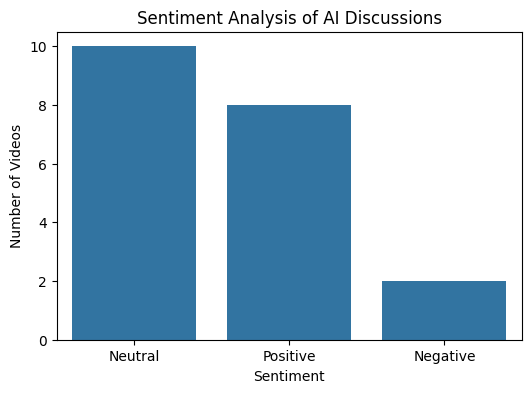


Top Keywords
          word  count
12          ai     23
60    tutorial     10
20   beginners      8
27      course      6
22       build      5
42       learn      4
45     minutes      4
17  artificial      3
51      python      3
4         2026      3


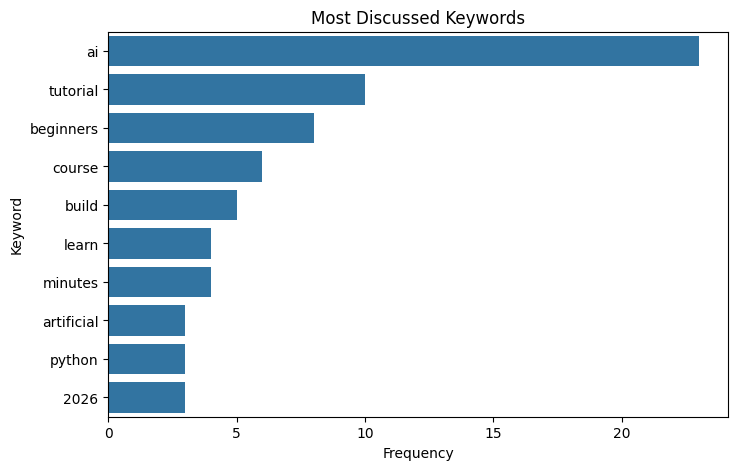


Most Active Channels
channel
Mikey No Code              3
Jeff Su                    2
Futurepedia                2
Dan Martell                1
AI Master                  1
WebKnower                  1
edureka!                   1
Simplilearn                1
theMITmonk                 1
Kevin Stratvert            1
Kellan Henneberry          1
Ed Hill | AI Automation    1
AI Alfie                   1
Moritz | AI Builder        1
Roboverse                  1
freeCodeCamp.org           1
Name: count, dtype: int64


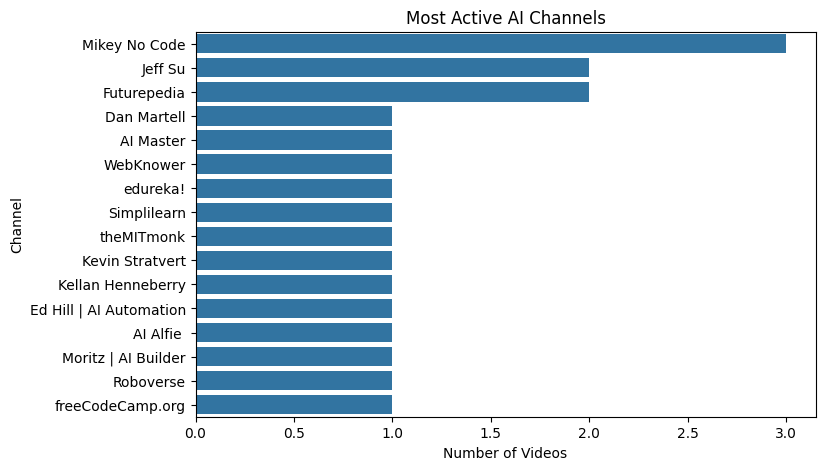

In [10]:
# ==========================================================
# PRACTICAL 10 : SOCIAL MEDIA TEXT ANALYTICS MODEL
# ==========================================================

# STEP 1: Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob
from sklearn.feature_extraction.text import CountVectorizer


# STEP 2: Load Dataset
data = pd.read_csv(r"C:\YouTube_Social_Media_Anlytics_Project\data\raw\youtube_data.csv")

print("Dataset Preview")
print(data.head())


# ==========================================================
# STEP 3: Sentiment Analysis
# ==========================================================

def get_sentiment(text):
    
    analysis = TextBlob(str(text))
    
    if analysis.sentiment.polarity > 0:
        return "Positive"
    
    elif analysis.sentiment.polarity < 0:
        return "Negative"
    
    else:
        return "Neutral"


data["sentiment"] = data["title"].apply(get_sentiment)

print("\nSentiment Distribution")
print(data["sentiment"].value_counts())


# ==========================================================
# GRAPH 1 : Sentiment Distribution
# ==========================================================

plt.figure(figsize=(6,4))

sns.countplot(x="sentiment", data=data)

plt.title("Sentiment Analysis of AI Discussions")

plt.xlabel("Sentiment")

plt.ylabel("Number of Videos")

plt.show()


# ==========================================================
# STEP 4: Keyword Extraction
# ==========================================================

vectorizer = CountVectorizer(stop_words="english")

X = vectorizer.fit_transform(data["title"])

word_freq = pd.DataFrame({
    "word": vectorizer.get_feature_names_out(),
    "count": X.toarray().sum(axis=0)
})

top_words = word_freq.sort_values(by="count", ascending=False).head(10)

print("\nTop Keywords")
print(top_words)


# ==========================================================
# GRAPH 2 : Top Keywords
# ==========================================================

plt.figure(figsize=(8,5))

sns.barplot(x="count", y="word", data=top_words)

plt.title("Most Discussed Keywords")

plt.xlabel("Frequency")

plt.ylabel("Keyword")

plt.show()


# ==========================================================
# STEP 5: Channel Activity
# ==========================================================

channel_activity = data["channel"].value_counts()

print("\nMost Active Channels")
print(channel_activity)


# ==========================================================
# GRAPH 3 : Channel Activity
# ==========================================================

plt.figure(figsize=(8,5))

sns.barplot(x=channel_activity.values, y=channel_activity.index)

plt.title("Most Active AI Channels")

plt.xlabel("Number of Videos")

plt.ylabel("Channel")

plt.show()